<a href="https://colab.research.google.com/github/GraceVortex/LSTM/blob/main/lstm_mcc_embed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!find /content/drive/MyDrive -name "df_embed.parquet"


/content/drive/MyDrive/ml/df_embed.parquet


In [5]:
df = pd.read_parquet('/content/drive/MyDrive/ml/df_embed.parquet')

In [6]:
df.drop(columns = ['merchant_mcc'], inplace = True)

In [7]:
df = df.rename(columns={'merchant_mcc_next': 'merchant_mcc'})


In [8]:
df['merchant_mcc'] = df['merchant_mcc'].astype('int32')


In [9]:
df['acquirer_country_iso'] =  df['acquirer_country_iso'].apply(lambda x: 0 if x == 1 else 1)

In [10]:
df['year'] =  df['year'].apply(lambda x: 0 if x == 1 else 1)

In [11]:
df.head()

,card_id,mcc_category,merchant_city,transaction_type,acquirer_country_iso,pos_entry_mode,wallet_type,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,dom_sin,dom_cos,mon_sin,mon_cos,year,transaction_currency_binary,amount_log_scaled,merchant_mcc
0,10000,5,5,2,0,1,0,1,-0.258819,0.965926,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.196927,12
1,10000,5,5,2,0,3,1,1,-0.965926,-0.258819,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.246532,2
2,10000,11,1,0,0,5,4,1,0.866025,-0.500000,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.493307,32
3,10000,8,5,2,0,1,0,1,0.500000,-0.866025,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.424723,12
4,10000,5,1,2,0,3,1,1,0.000000,1.000000,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.196058,2


In [12]:
import matplotlib.pyplot as plt

In [34]:
top10_card_ids = df['card_id'].value_counts(normalize=True).head(10) * 100
print(top10_card_ids)


card_id
10859    0.253193
10082    0.250364
11211    0.248818
11519    0.246061
10241    0.244821
11515    0.241423
11844    0.239221
10888    0.237383
11377    0.236727
10966    0.235618
Name: proportion, dtype: float64


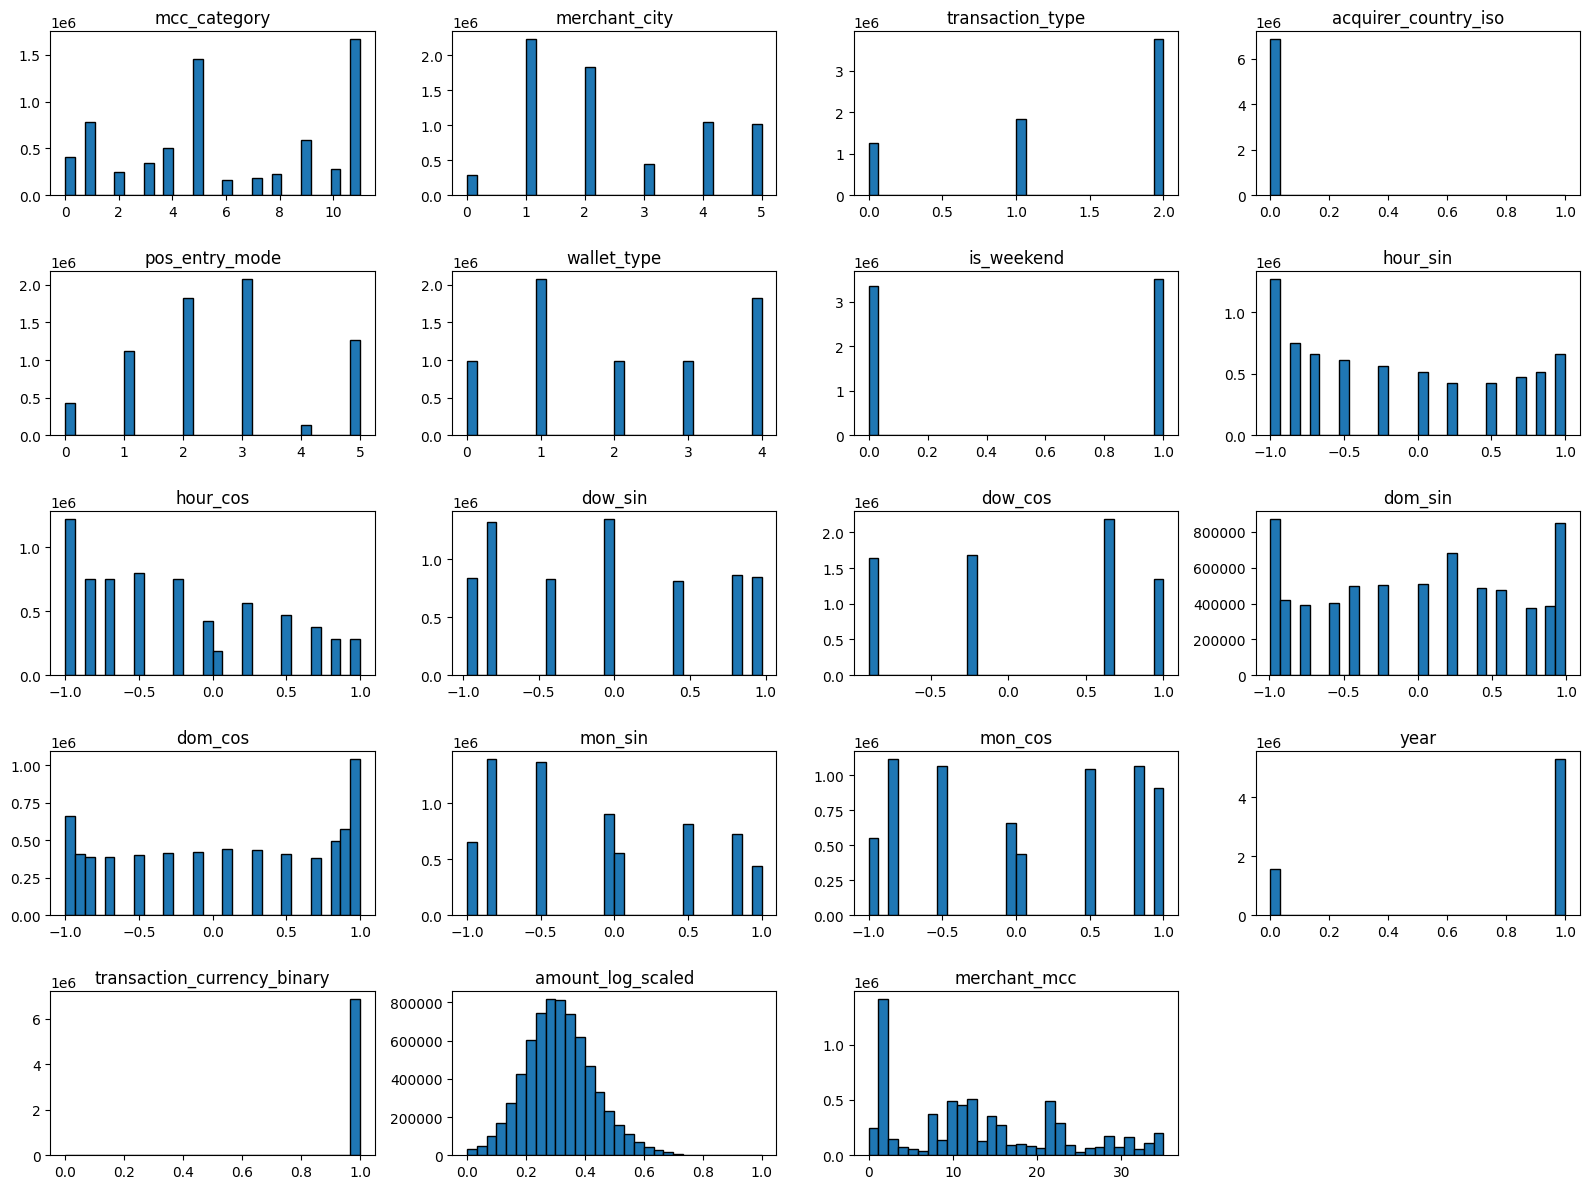

In [13]:
temp = df.drop(columns=['card_id'])

temp.hist(figsize=(16, 12), bins=30, grid=False, edgecolor='black')

plt.tight_layout()
plt.show()

In [14]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📦 Using device: {device}")


📦 Using device: cuda


In [15]:
num_of_epochs = 8

In [16]:
from torch.utils.data import Dataset
import torch

class EfficientSeqDataset(Dataset):
    def __init__(self, df, seq_len=50, cat_cols=None, cont_cols=None):
        self.df = df
        self.seq_len = seq_len
        self.cat_cols = cat_cols or []
        self.cont_cols = cont_cols or []
        self.indexes = []
        self.card_groups = dict(tuple(df.groupby('card_id')))
        for card_id, group in self.card_groups.items():
            if len(group) < seq_len + 1:
                continue
            for i in range(seq_len, len(group)):
                self.indexes.append((card_id, i))

    def __len__(self):
        return len(self.indexes)

    def __getitem__(self, idx):
        card_id, i = self.indexes[idx]
        group = self.card_groups[card_id]
        seq = group.iloc[i - self.seq_len:i]

        x_cat = seq[self.cat_cols].values.astype('int64')  # (seq_len, num_cat)
        x_cont = seq[self.cont_cols].values.astype('float32')  # (seq_len, num_cont)
        y = group['merchant_mcc'].iloc[i]

        return {
            'x_cat': torch.tensor(x_cat, dtype=torch.long),
            'x_cont': torch.tensor(x_cont, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long)
        }


In [17]:
import numpy as np

def split_df_by_card_id(df, train_frac=0.7, val_frac=0.15, test_frac=0.15, seed=42):
    # 1. unique card_id
    unique_ids = df['card_id'].unique()
    np.random.seed(seed)
    np.random.shuffle(unique_ids)

    n_total = len(unique_ids)
    n_train = int(n_total * train_frac)
    n_val = int(n_total * val_frac)

    train_ids = unique_ids[:n_train]
    val_ids = unique_ids[n_train:n_train + n_val]
    test_ids = unique_ids[n_train + n_val:]

    # 3.filter by card_id
    df_train = df[df['card_id'].isin(train_ids)]
    df_val = df[df['card_id'].isin(val_ids)]
    df_test = df[df['card_id'].isin(test_ids)]

    return df_train, df_val, df_test


In [26]:
df_train, df_val, df_test = split_df_by_card_id(df)
#create Datasets using torch.dataset
categorical_cols = [
    'mcc_category',
    'merchant_city',
    'transaction_type',
    'pos_entry_mode',
    'wallet_type',
    'acquirer_country_iso',
    'year',
    'transaction_currency_binary'
]
cont_cols = ['is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'dom_sin', 'dom_cos', 'mon_sin', 'mon_cos', 'amount_log_scaled']
df_train, df_val, df_test = split_df_by_card_id(df)

# Создание датасетов
train_dataset = EfficientSeqDataset(df_train, seq_len=30, cat_cols=categorical_cols, cont_cols=cont_cols)
val_dataset = EfficientSeqDataset(df_val, seq_len=30, cat_cols=categorical_cols, cont_cols=cont_cols)
test_dataset = EfficientSeqDataset(df_test, seq_len=30, cat_cols=categorical_cols, cont_cols=cont_cols)

# DataLoaders
from torch.utils.data import DataLoader

# Увеличение num_workers и включение pin_memory
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Number of workers for train_loader: {train_loader.num_workers}")
print(f"Pin memory enabled for train_loader: {train_loader.pin_memory}")

Number of workers for train_loader: 4
Pin memory enabled for train_loader: True


In [19]:
class ImprovedLSTMClassifier(nn.Module):
    def __init__(self, cat_dims, embedding_dim, cont_dim, hidden_size, num_classes, dropout=0.3):
        super().__init__()

        # Multiple embedding layers for each categorical feature
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_categories, embedding_dim) for num_categories in cat_dims
        ])
        total_emb_dim = embedding_dim * len(cat_dims)

        self.input_size = total_emb_dim + cont_dim

        self.lstm = nn.LSTM(
            input_size=self.input_size,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x_cat, x_cont):
        # x_cat: (batch, seq_len, num_cat_cols)
        # x_cont: (batch, seq_len, num_cont_cols)

        # Apply embedding to each categorical column
        embedded = [
            emb_layer(x_cat[:, :, i]) for i, emb_layer in enumerate(self.embeddings)
        ]

        x_cat_emb = torch.cat(embedded, dim=-1)  # (batch, seq_len, total_emb_dim)
        x = torch.cat([x_cat_emb, x_cont], dim=-1)  # (batch, seq_len, input_size)

        _, (h_n, _) = self.lstm(x)
        last_hidden = self.dropout(h_n[-1])
        return self.fc(last_hidden)


In [20]:
cat_dims = [df[col].nunique() for col in categorical_cols]  # [12, 6, 3, 6, 5, 2, 2, 2]
embedding_dim = 8
cont_dim = len(cont_cols)                           # 10
hidden_size = 128
num_classes = df['merchant_mcc'].nunique()

# Модель
model = ImprovedLSTMClassifier(
    cat_dims=cat_dims,
    embedding_dim=embedding_dim,
    cont_dim=cont_dim,
    hidden_size=hidden_size,
    num_classes=num_classes
).to(device)

In [21]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01)
# Add Cosine Annealing LR scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=num_of_epochs * len(train_loader)) # T_max is the total number of training iterations

In [22]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import torch.nn.functional as F

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, epsilon: float = 0.1, reduction='mean'):
        super().__init__()
        self.epsilon = epsilon
        self.reduction = reduction

    def forward(self, x, target):
        num_classes = x.size()[-1]
        log_prob = F.log_softmax(x, dim=-1)
        # Original NLLLoss
        nll_loss = -log_prob.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        if self.reduction == 'mean':
            nll_loss = nll_loss.mean()
        elif self.reduction == 'sum':
            nll_loss = nll_loss.sum()

        # Smoothed loss (KLDivLoss with uniform distribution)
        smooth_loss = -log_prob.mean(dim=-1)
        if self.reduction == 'mean':
            smooth_loss = smooth_loss.mean()
        elif self.reduction == 'sum':
            smooth_loss = smooth_loss.sum()

        loss = (1.0 - self.epsilon) * nll_loss + self.epsilon * smooth_loss
        return loss

# Calculate class weights (commented out as in the original notebook)
'''class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['merchant_mcc']),
    y=df_train['merchant_mcc']
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)'''


criterion = LabelSmoothingCrossEntropy(epsilon=0.1)

In [23]:
from sklearn.metrics import f1_score

def topk_accuracy(outputs, targets, k):
    """
    Calculates the Top-k accuracy.

    Args:
        outputs (torch.Tensor): Model outputs (logits).
        targets (torch.Tensor): Ground truth targets.
        k (int): The number of top predictions to consider.

    Returns:
        float: Top-k accuracy as a percentage.
    """
    num_classes = outputs.size(1)
    if k > num_classes:
        k = num_classes  # prevent error

    _, topk_preds = torch.topk(outputs, k, dim=1)
    targets_expanded = targets.view(-1, 1).expand_as(topk_preds)
    correct = torch.sum(topk_preds == targets_expanded).item()
    return correct / targets.size(0) * 100

def calculate_topk_accuracies(outputs, targets, ks):
    """
    Calculates Top-k accuracies for a list of k values.

    Args:
        outputs (torch.Tensor): Model outputs (logits).
        targets (torch.Tensor): Ground truth targets.
        ks (list): A list of integers representing the top-k values to calculate.

    Returns:
        dict: A dictionary where keys are k values and values are the corresponding top-k accuracies.
    """
    topk_results = {}
    for k in ks:
        topk_results[f'Top-{k} Accuracy'] = topk_accuracy(outputs, targets, k)
    return topk_results

def calculate_f1_score(outputs, targets, average='weighted'):
    """
    Calculates the F1 score.

    Args:
        outputs (torch.Tensor): Model outputs (logits).
        targets (torch.Tensor): Ground truth targets.
        average (str): The type of averaging to perform for the F1 score.

    Returns:
        float: F1 score.
    """
    _, predicted = torch.max(outputs, dim=1)
    # Move tensors to CPU for sklearn
    predicted_cpu = predicted.cpu().numpy()
    targets_cpu = targets.cpu().numpy()
    return f1_score(targets_cpu, predicted_cpu, average=average)

In [28]:
import torch
from tqdm import tqdm
import math
import torch.amp as amp # Corrected import

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📦 Using device: {device}")

# Instantiate the ImprovedLSTMClassifier instead of the RNN classifier
model = ImprovedLSTMClassifier(
    cat_dims=cat_dims,
    embedding_dim=embedding_dim,
    cont_dim=cont_dim,
    hidden_size=hidden_size,
    num_classes=num_classes
).to(device)

# Print device of model parameters
print(f"Model is on device: {next(model.parameters()).device}")


optimizer = torch.optim.AdamW(model.parameters(), lr=0.00001, weight_decay=0.01)
criterion = LabelSmoothingCrossEntropy(epsilon=0.1)

train_losses = []
val_losses = []
val_accuracies = []
val_top3_accuracies = []
val_top5_accuracies = []
val_f1_scores = []

num_of_epochs = 8

# Early stopping parameters
patience = 3
min_delta = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0

# Initialize GradScaler for Automatic Mixed Precision
# Corrected GradScaler initialization
scaler = amp.GradScaler(enabled=device.type == 'cuda')


for epoch in range(num_of_epochs):
    model.train()
    total_train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_of_epochs}", leave=False)

    for i, batch in enumerate(loop): # Added enumeration to get batch index
            x_cat = batch['x_cat'].to(device)
            x_cont = batch['x_cont'].to(device)
            y = batch['y'].to(device)

            # Print device of input tensors for the first batch of the first epoch
            if epoch == 0 and i == 0:
                print(f"x_cat batch device: {x_cat.device}")
                print(f"x_cont batch device: {x_cont.device}")
                print(f"y batch device: {y.device}")

            optimizer.zero_grad()

            # Use autocast for mixed precision
            # Corrected autocast usage
            with amp.autocast(device_type=device.type, dtype=torch.float16):
                outputs = model(x_cat, x_cont)
                loss = criterion(outputs, y)

            # Scale the loss and perform backward pass
            scaler.scale(loss).backward()

            # Unscale gradients and clip
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update weights using scaled gradients
            scaler.step(optimizer)

            # Update the scaler for the next iteration
            scaler.update()

            total_train_loss += loss.item()
            loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    all_targets = []
    all_outputs = []

    for batch in val_loader:
            x_cat = batch['x_cat'].to(device)
            x_cont = batch['x_cont'].to(device)
            y_val = batch['y'].to(device)

            # Use autocast for mixed precision during evaluation as well
            # Corrected autocast usage
            with amp.autocast(device_type=device.type, dtype=torch.float16):
                outputs = model(x_cat, x_cont)
                loss = criterion(outputs, y_val)

            total_val_loss += loss.item()

            all_targets.append(y_val)
            all_outputs.append(outputs)

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Concatenate all targets and outputs for metric calculations
    all_targets = torch.cat(all_targets)
    all_outputs = torch.cat(all_outputs)

    # Calculate and store metrics (move outputs to CPU if necessary for sklearn)
    acc = topk_accuracy(all_outputs.float(), all_targets, k=1) # Ensure float for accuracy
    top3_acc = topk_accuracy(all_outputs.float(), all_targets, k=3)
    top5_acc = topk_accuracy(all_outputs.float(), all_targets, k=5)
    f1 = calculate_f1_score(all_outputs.float(), all_targets) # Ensure float for f1_score

    val_accuracies.append(acc)
    val_top3_accuracies.append(top3_acc)
    val_top5_accuracies.append(top5_acc)
    val_f1_scores.append(f1)


    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc (Top-1): {acc:.4f}% | Val Acc (Top-3): {top3_acc:.4f}% | Val Acc (Top-5): {top5_acc:.4f}% | Val F1 Score (weighted): {f1:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss.")
            break

📦 Using device: cuda
Model is on device: cuda:0


Epoch 1/8:   0%|          | 10/151823 [00:00<2:31:54, 16.66it/s, loss=3.56]

x_cat batch device: cuda:0
x_cont batch device: cuda:0
y batch device: cuda:0


Epoch 1 | Train Loss: 3.0427 | Val Loss: 3.0022 | Val Acc (Top-1): 22.3641% | Val Acc (Top-3): 38.4061% | Val Acc (Top-5): 51.0172% | Val F1 Score (weighted): 0.1390


Epoch 2 | Train Loss: 2.9696 | Val Loss: 2.9845 | Val Acc (Top-1): 22.7334% | Val Acc (Top-3): 38.7982% | Val Acc (Top-5): 51.4457% | Val F1 Score (weighted): 0.1510


Epoch 3 | Train Loss: 2.9394 | Val Loss: 2.9807 | Val Acc (Top-1): 22.6578% | Val Acc (Top-3): 38.9341% | Val Acc (Top-5): 51.6211% | Val F1 Score (weighted): 0.1564


Epoch 4 | Train Loss: 2.9179 | Val Loss: 2.9831 | Val Acc (Top-1): 22.6570% | Val Acc (Top-3): 38.7335% | Val Acc (Top-5): 51.5482% | Val F1 Score (weighted): 0.1518


Epoch 5 | Train Loss: 2.8997 | Val Loss: 2.9837 | Val Acc (Top-1): 22.5846% | Val Acc (Top-3): 38.7744% | Val Acc (Top-5): 51.6290% | Val F1 Score (weighted): 0.1541


Epoch 6 | Train Loss: 2.8843 | Val Loss: 2.9839 | Val Acc (Top-1): 22.6225% | Val Acc (Top-3): 38.8557% | Val Acc (Top-5): 51.6538% | Val F1 Score (weighted): 0.1533
Early stopping triggered after 6 epochs due to no improvement in validation loss.


In [35]:
# Select a sample card_id from the dataframe
sample_card_id = df['card_id'].iloc[0] # You can choose any card_id

# Display the first 10 rows for this card_id
display(df[df['card_id'] == sample_card_id].head(10))

,card_id,mcc_category,merchant_city,transaction_type,acquirer_country_iso,pos_entry_mode,wallet_type,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,dom_sin,dom_cos,mon_sin,mon_cos,year,transaction_currency_binary,amount_log_scaled,merchant_mcc
0,10000,5,5,2,0,1,0,1,-0.258819,0.965926,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.196927,12
1,10000,5,5,2,0,3,1,1,-0.965926,-0.258819,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.246532,2
2,10000,11,1,0,0,5,4,1,0.866025,-0.500000,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.493307,32
3,10000,8,5,2,0,1,0,1,0.500000,-0.866025,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.424723,12
4,10000,5,1,2,0,3,1,1,0.000000,1.000000,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.196058,2
5,10000,11,1,0,0,5,4,1,-0.965926,0.258819,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.188406,12
6,10000,5,1,1,0,2,3,1,-0.258819,-0.965926,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.222464,12
7,10000,5,1,1,0,2,3,1,-0.866025,-0.500000,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.271878,8
8,10000,4,1,1,0,2,0,1,-0.707107,0.707107,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.339715,12
10,10000,5,5,2,0,4,4,1,-0.500000,-0.866025,-0.781832,0.62349,0.587785,-0.809017,-0.866025,-0.5,0,1,0.265114,2


In [36]:
kf# Клонируем репозиторий
!git clone https://github.com/GraceVortex/mccpred.git

# Переходим в директорию репозитория
%cd mccpred

# Копируем файл ноутбука в директорию репозитория
# Замените 'your_notebook_name.ipynb' на фактическое имя вашего файла ноутбука в Colab
!cp /content/your_notebook_name.ipynb .

# Добавляем файл ноутбука в staging area
!git add your_notebook_name.ipynb

# Делаем коммит
# Замените "Add notebook" на осмысленное сообщение коммита
!git commit -m "Add notebook"

# Отправляем изменения в удаленный репозиторий
!git push origin main

Cloning into 'mccpred'...
/content/mccpred
cp: cannot stat '/content/your_notebook_name.ipynb': No such file or directory
fatal: pathspec 'your_notebook_name.ipynb' did not match any files
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@48485d7afbd8.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/GraceVortex/mccpred.git'


In [37]:
# Настройка имени пользователя и email для Git (если вы еще не делали это успешно)
# Замените на ваши реальные данные
!git config --global user.email "orynbekdulat6@gmail.com"
!git config --global user.name "Grace Vortex"

In [40]:
# Клонируем репозиторий (если еще не клонировали)
# Убедитесь, что вы не пытаетесь клонировать в существующую непустую директорию
!git clone https://github.com/GraceVortex/mccpred.git

# Переходим в директорию репозитория
%cd mccpred

# Копируем файл ноутбука в директорию репозитория
# Убедитесь, что путь к вашему ноутбуку правильный
!cp /content/lstm_mcc_embed.ipynb .

# Добавляем файл ноутбука в staging area
!git add lstm_mcc_embed.ipynb

# Проверяем статус, чтобы убедиться, что файл добавлен
!git status

# Делаем коммит
!git commit -m "Add notebook"

# Отправляем изменения в удаленный репозиторий
# При запросе учетных данных используйте логин GitHub и Personal Access Token
!git push -u origin main

Cloning into 'mccpred'...
/content/mccpred/mccpred/mccpred/mccpred
cp: cannot stat '/content/lstm_mcc_embed.ipynb': No such file or directory
fatal: pathspec 'lstm_mcc_embed.ipynb' did not match any files
On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/GraceVortex/mccpred.git'


In [41]:
# Переходим в корневую директорию Colab
%cd /content/

# Удаляем старую директорию репозитория (если она существует)
!rm -rf mccpred

# Клонируем репозиторий заново
!git clone https://github.com/GraceVortex/mccpred.git

# Переходим в правильную директорию репозитория
%cd mccpred

# Проверяем текущую директорию
!pwd

# Копируем файл ноутбука в директорию репозитория
# Убедитесь, что путь к вашему ноутбуку правильный
!cp /content/lstm_mcc_embed.ipynb .

# Добавляем файл ноутбука в staging area
!git add lstm_mcc_embed.ipynb

# Проверяем статус, чтобы убедиться, что файл добавлен
!git status

# Делаем коммит
!git commit -m "Add notebook lstm_mcc_embed.ipynb"

# Отправляем изменения в удаленный репозиторий
# При запросе учетных данных используйте логин GitHub и Personal Access Token
!git push -u origin main

/content
Cloning into 'mccpred'...
/content/mccpred
/content/mccpred
cp: cannot stat '/content/lstm_mcc_embed.ipynb': No such file or directory
fatal: pathspec 'lstm_mcc_embed.ipynb' did not match any files
On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/GraceVortex/mccpred.git'


In [42]:
!ls /content/

drive  mccpred	sample_data
